# Week 2-2: Transform 심화 - 비즈니스 테이블 만들고 분석하기

이번 실습은 지난 시간에 만든 `movies_clean` 중간 테이블에서 출발합니다.

목표는 원본 데이터를 한 번 더 다듬고 조인해서 분석에 재사용할 수 있는 중간 테이블을 만들고, 그 중간 테이블을 바탕으로 사람이 바로 읽거나 BI/시각화에서 사용할 수 있는 비즈니스 테이블을 만드는 것입니다.

## 0. 이번 시간에 풀 비즈니스 질문

먼저 질문을 정하고 시작합니다. 그래야 왜 `keywords`를 붙이는지, 왜 `profit`, `roi` 같은 파생 컬럼을 만드는지 방향이 분명해집니다.

이번 실습에서 답할 질문은 다음과 같습니다.

1. **신뢰할 만한 고평점 영화는 어느 시기에 많았을까?**
   - 단순히 평점 평균만 보지 않고 `vote_count`도 함께 고려합니다.
2. **대표 키워드별로 수익성과 효율은 어떻게 다를까?**
   - 그래서 `keywords.csv`에서 `main_keyword`를 추출해 영화 정보에 붙입니다.
   - 그래서 `profit`, `roi` 파생 컬럼을 만듭니다.
3. **시기별로 어떤 대표 키워드가 많이 등장했을까?**
   - 연도 단위는 너무 듬성듬성할 수 있어서, 이번에는 `release_decade`를 사용합니다.
4. **wide table과 long table은 각각 언제 쓰기 좋을까?**
   - `pivot_table()`과 `melt()`를 비교합니다.

## 1. Transform의 3단계

이번 실습의 전체 흐름은 아래와 같습니다.

```text
raw
→ intermediate
→ business table
```

- raw: 아직 손대지 않은 원본 데이터
- intermediate: 정제, 조인, 파생 컬럼 생성이 끝난 재사용 가능한 중간 테이블
- business table: 특정 질문에 답하기 위해 집계/피벗된 최종 결과 테이블

## 2. 준비

In [37]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

sns.set_theme(style="whitegrid")

한글 시각화가 깨지지 않도록 사용 가능한 한글 폰트를 찾아 설정합니다.

Mac에서는 보통 `AppleGothic`, Windows에서는 `Malgun Gothic`, 일부 환경에서는 `NanumGothic`을 사용합니다.

In [38]:
font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}

for font_name in font_candidates:
    if font_name in available_fonts:
        rcParams["font.family"] = font_name
        break

rcParams["axes.unicode_minus"] = False

print("현재 matplotlib 폰트:", rcParams["font.family"])

현재 matplotlib 폰트: ['AppleGothic']


데이터 경로를 설정합니다. 노트북을 루트에서 실행해도, `week2/src`에서 실행해도 동작하도록 후보 경로를 둡니다.

In [39]:
DATA_DIR_CANDIDATES = [Path("../data"), Path("week2/data"), Path("data")]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError("data 폴더를 찾을 수 없습니다. download_dataset.py를 먼저 실행하세요.")

RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = DATA_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MOVIES_CLEAN_PATH = OUTPUT_DIR / "movies_clean_for_load.csv"
KEYWORDS_PATH = RAW_DIR / "keywords.csv"

MOVIES_WITH_KEYWORD_PATH = OUTPUT_DIR / "movies_with_keyword.csv"
YEAR_BUSINESS_PATH = OUTPUT_DIR / "year_business_table.csv"
KEYWORD_BUSINESS_WIDE_PATH = OUTPUT_DIR / "keyword_business_table_wide.csv"
KEYWORD_BUSINESS_LONG_PATH = OUTPUT_DIR / "keyword_business_table_long.csv"
DECADE_KEYWORD_PIVOT_PATH = OUTPUT_DIR / "decade_keyword_pivot.csv"

DATA_DIR

PosixPath('../data')

출력 숫자가 과학적 표기법(`1.367475e+07`)으로 보이면 처음 보는 입장에서 읽기 어렵습니다.

실습에서는 숫자를 조금 더 읽기 쉽게 보이도록 pandas 출력 포맷을 설정합니다.

In [40]:
pd.options.display.float_format = "{:,.2f}".format

## 3. 중간 테이블 읽기

지난 실습에서 만든 `movies_clean_for_load.csv`를 읽습니다.

이 파일은 이미 컬럼 선별, 자료형 변환, 결측치/중복/이상치 점검을 거친 중간 정제 테이블입니다.

In [41]:
movies_clean = pd.read_csv(MOVIES_CLEAN_PATH, parse_dates=["release_date"])

print("movies_clean shape:", movies_clean.shape)
movies_clean.head(3)

movies_clean shape: (43565, 11)


,movie_id,title,release_date,release_year,original_language,runtime,budget,revenue,popularity,vote_average,vote_count
0,862,Toy Story,1995-10-30,1995,en,81.00,"30,000,000.00","373,554,033.00",21.95,7.70,"5,415.00"
1,8844,Jumanji,1995-12-15,1995,en,104.00,"65,000,000.00","262,797,249.00",17.02,6.90,"2,413.00"
2,15602,Grumpier Old Men,1995-12-22,1995,en,101.00,0.00,0.00,11.71,6.50,92.00


In [42]:
movies_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 43565 entries, 0 to 43564
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   movie_id           43565 non-null  int64         
 1   title              43565 non-null  str           
 2   release_date       43565 non-null  datetime64[us]
 3   release_year       43565 non-null  int64         
 4   original_language  43565 non-null  str           
 5   runtime            43565 non-null  float64       
 6   budget             43565 non-null  float64       
 7   revenue            43565 non-null  float64       
 8   popularity         43565 non-null  float64       
 9   vote_average       43565 non-null  float64       
 10  vote_count         43565 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(2), str(2)
memory usage: 3.7 MB


이번 실습에서 사용할 주요 컬럼만 먼저 확인합니다.

In [43]:
movies_clean[[
    "movie_id", "title", "release_year", "vote_average", "vote_count", "budget", "revenue"
]].head(5)

,movie_id,title,release_year,vote_average,vote_count,budget,revenue
0,862,Toy Story,1995,7.70,"5,415.00","30,000,000.00","373,554,033.00"
1,8844,Jumanji,1995,6.90,"2,413.00","65,000,000.00","262,797,249.00"
2,15602,Grumpier Old Men,1995,6.50,92.00,0.00,0.00
3,31357,Waiting to Exhale,1995,6.10,34.00,"16,000,000.00","81,452,156.00"
4,11862,Father of the Bride Part II,1995,5.70,173.00,0.00,"76,578,911.00"


## 4. keywords 원본 확인

`keywords.csv`는 영화별 키워드 정보를 담고 있습니다.

주의할 점은 `keywords` 컬럼이 일반 문자열처럼 보이지만, 실제로는 리스트 형태의 값이 문자열로 저장되어 있다는 것입니다.

In [44]:
keywords_raw = pd.read_csv(KEYWORDS_PATH)

print("keywords_raw shape:", keywords_raw.shape)
keywords_raw.head(5)

keywords_raw shape: (46419, 2)


,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


### 참고: explode는 무엇인가?

`explode`는 한 행 안에 여러 값이 들어 있을 때, 그 여러 값을 여러 행으로 펼치는 작업입니다.

예를 들어 한 영화에 키워드가 3개 있으면 아래처럼 바꿀 수 있습니다.

```text
movie_id | keywords
862      | [toy, friendship, rivalry]
```

```text
movie_id | keyword
862      | toy
862      | friendship
862      | rivalry
```

이 방식은 정석적인 관계 테이블을 만들 때 좋지만, 이번 실습에서는 난이도를 낮추기 위해 전체 explode 대신 첫 번째 키워드 하나만 `main_keyword`로 사용합니다.

## 5. 첫 번째 키워드 추출 함수 만들기

첫 번째 키워드가 항상 가장 중요한 키워드라는 보장은 없습니다.

이번에는 `keywords` 데이터를 조인하고 집계하는 흐름을 보기 위해 단순화된 대표 키워드로 사용합니다.

In [45]:
def extract_first_keyword(keyword_text):
    if pd.isna(keyword_text):
        return np.nan

    try:
        parsed = ast.literal_eval(keyword_text)
    except (ValueError, SyntaxError):
        return np.nan

    if not isinstance(parsed, list) or len(parsed) == 0:
        return np.nan

    first_item = parsed[0]
    if not isinstance(first_item, dict):
        return np.nan

    return first_item.get("name", np.nan)

함수가 의도대로 동작하는지 원본 몇 개에 적용해 봅니다.

In [46]:
keywords_raw["keywords"].head(5).apply(extract_first_keyword)

0          jealousy
1        board game
2           fishing
3    based on novel
4              baby
Name: keywords, dtype: str

## 6. keywords_clean 만들기

원본 `keywords.csv`에서 이번 실습에 필요한 정보만 남겨 `keywords_clean`을 만듭니다.

지난 실습에서 `movies_metadata`를 정제했던 것처럼, 여기서도 같은 흐름으로 진행합니다.

- 필요한 컬럼만 선택
- 조인 키 이름을 `movie_id`로 표준화
- 조인 키 자료형 변환
- 대표 키워드 `main_keyword` 생성
- 결측치와 중복 확인
- 영화 1개당 1행이 되도록 정리

In [47]:
keywords_clean = keywords_raw[["id", "keywords"]].copy()
keywords_clean = keywords_clean.rename(columns={"id": "movie_id"})

keywords_clean.head(3)

,movie_id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."


`keywords_clean`은 이후 `movies_clean`과 조인할 중간 테이블입니다.

따라서 한 영화가 여러 번 반복되지 않도록 `movie_id` 기준 중복을 확인하고 정리합니다. 이 과정은 지난 실습의 중복 제거와 같은 품질 점검 단계입니다.

In [48]:
keywords_clean["movie_id"] = pd.to_numeric(keywords_clean["movie_id"], errors="coerce")
keywords_clean["main_keyword"] = keywords_clean["keywords"].apply(extract_first_keyword)

keywords_clean = keywords_clean[["movie_id", "main_keyword"]].copy()
keywords_clean = keywords_clean.dropna(subset=["movie_id"])
keywords_clean["movie_id"] = keywords_clean["movie_id"].astype("int64")

print("중복 제거 전 keywords_clean row 수:", len(keywords_clean))
print("중복 제거 전 movie_id 중복 수:", keywords_clean["movie_id"].duplicated().sum())

# 이번 실습에서는 영화 1개당 대표 키워드 1개만 사용하므로 movie_id 기준 1행만 남긴다.
keywords_clean = keywords_clean.drop_duplicates(subset=["movie_id"], keep="first").copy()

print("중복 제거 후 keywords_clean row 수:", len(keywords_clean))
print("중복 제거 후 movie_id 중복 수:", keywords_clean["movie_id"].duplicated().sum())

keywords_clean.head(10)

중복 제거 전 keywords_clean row 수: 46419
중복 제거 전 movie_id 중복 수: 987
중복 제거 후 keywords_clean row 수: 45432
중복 제거 후 movie_id 중복 수: 0


,movie_id,main_keyword
0,862,jealousy
1,8844,board game
2,15602,fishing
3,31357,based on novel
4,11862,baby
5,949,robbery
6,11860,paris
7,45325,NaN
8,9091,terrorist
9,710,cuba


In [49]:
keywords_clean.isnull().sum()

movie_id            0
main_keyword    14340
dtype: int64

## 7. 조인 전 점검

조인하기 전에 양쪽 테이블의 키 컬럼을 확인합니다.

확인할 내용은 단순합니다.

- `movie_id` 자료형이 같은가
- 기준 키에 중복이 남아 있지 않은가
- 조인 후에도 영화 1개당 1행 구조가 유지될 수 있는가

In [50]:
movies_clean["movie_id"] = pd.to_numeric(movies_clean["movie_id"], errors="coerce")
movies_clean = movies_clean.dropna(subset=["movie_id"]).copy()
movies_clean["movie_id"] = movies_clean["movie_id"].astype("int64")

In [51]:
print("movies_clean movie_id dtype:", movies_clean["movie_id"].dtype)
print("keywords_clean movie_id dtype:", keywords_clean["movie_id"].dtype)
print("movies_clean row 수:", len(movies_clean))
print("keywords_clean row 수:", len(keywords_clean))
print("movies_clean movie_id 중복 수:", movies_clean["movie_id"].duplicated().sum())
print("keywords_clean movie_id 중복 수:", keywords_clean["movie_id"].duplicated().sum())

movies_clean movie_id dtype: int64
keywords_clean movie_id dtype: int64
movies_clean row 수: 43565
keywords_clean row 수: 45432
movies_clean movie_id 중복 수: 0
keywords_clean movie_id 중복 수: 0


## 8. movies_clean + keywords_clean 조인

`movies_clean`과 `keywords_clean`을 `movie_id` 기준으로 조인합니다.

이번 데이터에서는 두 테이블이 대부분 같은 영화 ID를 공유하므로 `inner join`을 사용합니다.

`inner join`은 두 테이블에 모두 존재하는 `movie_id`만 남기는 조인입니다. `main_keyword`가 비어 있는지는 조인 조건이 아니므로, `movie_id`가 매칭되면 `main_keyword`가 `NaN`이어도 결과에 남습니다.

키워드가 실제로 있는 영화만 분석할 때는 이후 분석 단계에서 `main_keyword` 결측을 제거합니다.

In [52]:
movies_with_keyword = movies_clean.merge(
    keywords_clean,
    on="movie_id",
    how="inner",
)

print("movies_with_keyword shape:", movies_with_keyword.shape)
movies_with_keyword.head(5)

movies_with_keyword shape: (43565, 12)


,movie_id,title,release_date,release_year,original_language,runtime,budget,revenue,popularity,vote_average,vote_count,main_keyword
0,862,Toy Story,1995-10-30,1995,en,81.00,"30,000,000.00","373,554,033.00",21.95,7.70,"5,415.00",jealousy
1,8844,Jumanji,1995-12-15,1995,en,104.00,"65,000,000.00","262,797,249.00",17.02,6.90,"2,413.00",board game
2,15602,Grumpier Old Men,1995-12-22,1995,en,101.00,0.00,0.00,11.71,6.50,92.00,fishing
3,31357,Waiting to Exhale,1995-12-22,1995,en,127.00,"16,000,000.00","81,452,156.00",3.86,6.10,34.00,based on novel
4,11862,Father of the Bride Part II,1995-02-10,1995,en,106.00,0.00,"76,578,911.00",8.39,5.70,173.00,baby


In [53]:
print("조인 전 movies_clean row 수:", len(movies_clean))
print("조인 후 movies_with_keyword row 수:", len(movies_with_keyword))
print("조인 후 movie_id 중복 수:", movies_with_keyword["movie_id"].duplicated().sum())
print("main_keyword 결측 수:", movies_with_keyword["main_keyword"].isna().sum())

조인 전 movies_clean row 수: 43565
조인 후 movies_with_keyword row 수: 43565
조인 후 movie_id 중복 수: 0
main_keyword 결측 수: 12936


In [54]:
print("movies_clean row 수:", len(movies_clean))
print("inner join 후 movies_with_keyword row 수:", len(movies_with_keyword))
print("조인 후 movie_id 중복 수:", movies_with_keyword["movie_id"].duplicated().sum())
print("main_keyword 결측 수:", movies_with_keyword["main_keyword"].isna().sum())

movies_clean row 수: 43565
inner join 후 movies_with_keyword row 수: 43565
조인 후 movie_id 중복 수: 0
main_keyword 결측 수: 12936


## 9. 비즈니스 질문을 위한 파생 컬럼 만들기

대표 키워드별 수익성과 효율을 보려면 `profit`, `roi`가 필요합니다.

- `profit`: 수익 - 예산
- `roi`: 수익 / 예산

`budget`이 0이면 `roi`를 계산하기 어렵기 때문에 `NaN`으로 둡니다.

In [55]:
movies_with_keyword["profit"] = movies_with_keyword["revenue"] - movies_with_keyword["budget"]

In [56]:
movies_with_keyword["roi"] = np.where(
    movies_with_keyword["budget"].notna() & (movies_with_keyword["budget"] > 0),
    movies_with_keyword["revenue"] / movies_with_keyword["budget"],
    np.nan,
)

연도별 pivot이 너무 듬성듬성해지는 문제를 줄이기 위해 `release_decade`도 만듭니다.

In [57]:
movies_with_keyword["release_decade"] = (movies_with_keyword["release_year"] // 10) * 10
movies_with_keyword["release_decade"] = movies_with_keyword["release_decade"].astype("Int64")

In [58]:
movies_with_keyword[[
    "title", "release_year", "release_decade", "budget", "revenue", "profit", "roi", "main_keyword"
]].head(5)

,title,release_year,release_decade,budget,revenue,profit,roi,main_keyword
0,Toy Story,1995,1990,"30,000,000.00","373,554,033.00","343,554,033.00",12.45,jealousy
1,Jumanji,1995,1990,"65,000,000.00","262,797,249.00","197,797,249.00",4.04,board game
2,Grumpier Old Men,1995,1990,0.00,0.00,0.00,NaN,fishing
3,Waiting to Exhale,1995,1990,"16,000,000.00","81,452,156.00","65,452,156.00",5.09,based on novel
4,Father of the Bride Part II,1995,1990,0.00,"76,578,911.00","76,578,911.00",NaN,baby


## 10. 중간 테이블 저장

`movies_with_keyword`는 아직 최종 집계표가 아닙니다.

한 행이 한 영화를 의미하고, 여러 분석에 재사용할 수 있으므로 중간 테이블로 저장합니다.

In [59]:
movies_with_keyword.to_csv(MOVIES_WITH_KEYWORD_PATH, index=False)
MOVIES_WITH_KEYWORD_PATH

PosixPath('../data/output/movies_with_keyword.csv')

## 11. 질문 1: 신뢰할 만한 고평점 영화는 어느 시기에 많았을까?

평점 평균(`vote_average`)만 보면 평가 수가 너무 적은 영화가 과하게 좋아 보일 수 있습니다.

그래서 이번에는 다음 조건을 함께 사용합니다.

- `vote_average >= 7.0`
- `vote_count >= 100`

이렇게 하면 “평점도 높고, 어느 정도 평가 수도 있는 영화”를 볼 수 있습니다.

In [60]:
reliable_high_rating_movies = movies_with_keyword[
    (movies_with_keyword["vote_average"] >= 7.0) &
    (movies_with_keyword["vote_count"] >= 100)
].copy()

print("신뢰 기준을 통과한 고평점 영화 수:", len(reliable_high_rating_movies))
reliable_high_rating_movies[["title", "release_year", "vote_average", "vote_count"]].head(10)

신뢰 기준을 통과한 고평점 영화 수: 1765


,title,release_year,vote_average,vote_count
0,Toy Story,1995,7.70,"5,415.00"
5,Heat,1995,7.70,"1,886.00"
12,Balto,1995,7.10,423.00
15,Casino,1995,7.80,"1,343.00"
16,Sense and Sensibility,1995,7.20,364.00
24,Leaving Las Vegas,1995,7.10,365.00
28,The City of Lost Children,1995,7.60,308.00
31,Twelve Monkeys,1995,7.40,"2,470.00"
35,Dead Man Walking,1995,7.30,350.00
46,Se7en,1995,8.10,"5,915.00"


In [61]:
high_rating_by_year = (
    reliable_high_rating_movies
    .groupby("release_year")
    .agg(
        high_rating_movie_count=("title", "count"),
        avg_rating=("vote_average", "mean"),
        avg_vote_count=("vote_count", "mean"),
    )
    .reset_index()
    .sort_values("high_rating_movie_count", ascending=False)
)

high_rating_by_year.head(10)

,release_year,high_rating_movie_count,avg_rating,avg_vote_count
95,2014,92,7.45,"1,744.48"
97,2016,77,7.45,"1,395.88"
96,2015,77,7.42,"1,552.12"
94,2013,71,7.40,"1,482.85"
90,2009,60,7.35,"1,419.98"
91,2010,55,7.36,"1,513.62"
88,2007,55,7.32,997.53
93,2012,55,7.31,"1,572.09"
92,2011,53,7.32,"1,302.06"
89,2008,50,7.42,"1,271.96"


## 12. 질문 2: 영화가 많이 나온 시기와 평균 평점이 높은 시기는 같을까?

이번에는 연도별로 영화 수, 평균 평점, 평균 투표 수, 평균 수익을 함께 봅니다.

`pd.options.display.float_format`을 설정했기 때문에 큰 숫자도 과학적 표기법 대신 쉼표가 들어간 숫자로 보입니다.

In [62]:
year_summary = (
    movies_with_keyword
    .groupby("release_year")
    .agg(
        movie_count=("title", "count"),
        avg_rating=("vote_average", "mean"),
        avg_vote_count=("vote_count", "mean"),
        avg_revenue=("revenue", "mean"),
    )
    .reset_index()
)

year_summary.head(10)

,release_year,movie_count,avg_rating,avg_vote_count,avg_revenue
0,1874,1,6.00,19.00,0.00
1,1878,1,6.20,25.00,0.00
2,1883,1,5.40,7.00,0.00
3,1887,1,4.10,17.00,0.00
4,1888,2,5.15,21.50,0.00
5,1890,5,4.74,8.60,0.00
6,1891,6,4.23,7.67,0.00
7,1892,3,3.47,10.67,0.00
8,1893,1,5.80,19.00,0.00
9,1894,13,5.29,8.46,0.00


In [63]:
year_summary.sort_values("movie_count", ascending=False).head(10)

,release_year,movie_count,avg_rating,avg_vote_count,avg_revenue
129,2014,1870,5.70,188.65,"14,098,157.23"
128,2013,1801,5.80,191.48,"14,806,372.27"
130,2015,1796,5.79,175.07,"16,041,333.63"
127,2012,1645,5.68,175.47,"15,829,253.71"
126,2011,1586,5.72,153.40,"15,296,759.39"
131,2016,1539,5.88,200.34,"19,816,683.89"
124,2009,1506,5.66,144.74,"15,517,958.75"
125,2010,1414,5.76,165.54,"16,579,125.55"
123,2008,1408,5.60,137.09,"14,668,959.49"
122,2007,1264,5.71,133.05,"15,588,182.84"


In [64]:
year_summary.sort_values("avg_rating", ascending=False).head(10)

,release_year,movie_count,avg_rating,avg_vote_count,avg_revenue
17,1902,2,6.90,159.00,0.00
39,1924,39,6.61,13.51,"31,125.13"
38,1923,23,6.53,13.70,27.09
43,1928,63,6.40,14.67,"43,137.27"
25,1910,7,6.37,8.71,0.00
23,1908,6,6.28,9.50,0.00
1,1878,1,6.20,25.00,0.00
34,1919,23,6.15,6.91,0.00
20,1905,5,6.08,8.60,0.00
35,1920,28,6.07,18.96,0.00


## 13. 질문 3: 시기별로 어떤 대표 키워드가 많이 등장했을까?

처음에는 `연도 x 키워드` pivot을 생각할 수 있습니다.

하지만 실제로 해보면 연도와 키워드 조합이 너무 잘게 쪼개져 빈칸이 많아질 수 있습니다. 그래서 이번 실습에서는 `연대 x 대표 키워드`로 바꿔서 봅니다.

In [65]:
movies_keyword_only = movies_with_keyword.dropna(subset=["main_keyword", "release_decade"]).copy()

top_keywords = (
    movies_keyword_only["main_keyword"]
    .value_counts()
    .head(8)
    .index
    .tolist()
)

top_keywords

['woman director',
 'independent film',
 'based on novel',
 'musical',
 'female nudity',
 'sex',
 'prison',
 'suicide']

In [66]:
movies_keyword_top = movies_keyword_only[
    movies_keyword_only["main_keyword"].isin(top_keywords)
].copy()

movies_keyword_top[["title", "release_decade", "main_keyword"]].head(10)

,title,release_decade,main_keyword
3,Waiting to Exhale,1990,based on novel
35,Dead Man Walking,1990,prison
52,Lamerica,1990,independent film
81,Antonia's Line,1990,suicide
125,The Silences of the Palace,1990,woman director
128,Angela,1990,independent film
146,Amateur,1990,independent film
163,The Doom Generation,1990,sex
167,Hackers,1990,female nudity
177,Mallrats,1990,sex


In [67]:
decade_keyword_pivot = movies_keyword_top.pivot_table(
    index="release_decade",
    columns="main_keyword",
    values="title",
    aggfunc="count",
    fill_value=0,
)

decade_keyword_pivot

main_keyword,based on novel,female nudity,independent film,musical,prison,sex,suicide,woman director
release_decade,,,,,,,,
1890,1,0,0,0,0,0,0,0
1900,1,0,0,0,0,0,0,0
1910,0,0,0,0,0,0,2,3
1920,2,0,1,6,3,0,2,1
1930,8,0,2,54,14,1,5,3
1940,8,2,1,64,15,0,8,2
1950,39,2,7,40,15,0,8,6
1960,40,21,12,28,12,16,13,12
1970,45,98,21,29,31,43,23,27


## 14. 질문 4: 대표 키워드별 수익성과 효율은 어떻게 다를까?

이제 대표 키워드별로 여러 지표를 함께 계산합니다.

이번 결과는 특정 질문에 답하기 위해 만들어진 비즈니스 테이블에 가깝습니다.

In [68]:
keyword_business = (
    movies_keyword_top
    .groupby("main_keyword")
    .agg(
        movie_count=("title", "count"),
        avg_rating=("vote_average", "mean"),
        avg_vote_count=("vote_count", "mean"),
        avg_revenue=("revenue", "mean"),
        avg_profit=("profit", "mean"),
        avg_roi=("roi", "mean"),
    )
    .reset_index()
    .sort_values("movie_count", ascending=False)
)

keyword_business

,main_keyword,movie_count,avg_rating,avg_vote_count,avg_revenue,avg_profit,avg_roi
7,woman director,1237,5.38,12.06,"248,151.73","-7,262.02",0.65
2,independent film,684,5.62,19.03,"398,780.81","-284,940.03",0.95
0,based on novel,436,5.91,363.42,"34,604,296.92","21,760,708.85",3.53
3,musical,382,5.38,33.87,"3,597,341.55","1,451,739.41",1.62
1,female nudity,365,5.37,68.18,"4,904,605.76","2,498,092.72",4.70
5,sex,304,5.72,73.37,"5,430,668.63","2,465,264.65",2.09
4,prison,281,6.10,226.55,"18,797,777.01","10,219,213.78",2.05
6,suicide,275,5.99,159.41,"9,916,163.37","5,097,337.62",1.54


## 15. wide table과 long table

`keyword_business`는 사람이 표로 읽기 좋은 wide table입니다.

하지만 여러 지표를 같은 방식으로 시각화하거나 추가 가공하려면 `metric`, `value` 구조의 long table이 더 편할 때가 많습니다.

In [69]:
keyword_business_long = keyword_business.melt(
    id_vars="main_keyword",
    value_vars=["movie_count", "avg_rating", "avg_vote_count", "avg_revenue", "avg_profit", "avg_roi"],
    var_name="metric",
    value_name="value",
)

keyword_business_long.head(12)

,main_keyword,metric,value
0,woman director,movie_count,"1,237.00"
1,independent film,movie_count,684.00
2,based on novel,movie_count,436.00
3,musical,movie_count,382.00
4,female nudity,movie_count,365.00
5,sex,movie_count,304.00
6,prison,movie_count,281.00
7,suicide,movie_count,275.00
8,woman director,avg_rating,5.38
9,independent film,avg_rating,5.62


## 16. long table을 활용한 시각화

아래 시각화 코드는 직접 작성하는 대상이라기보다, `melt()` 이후 long format이 왜 시각화에 편한지 보여주기 위한 예시입니다.

지표마다 단위와 스케일이 다르므로 `sharey=False`로 나누어 봅니다.

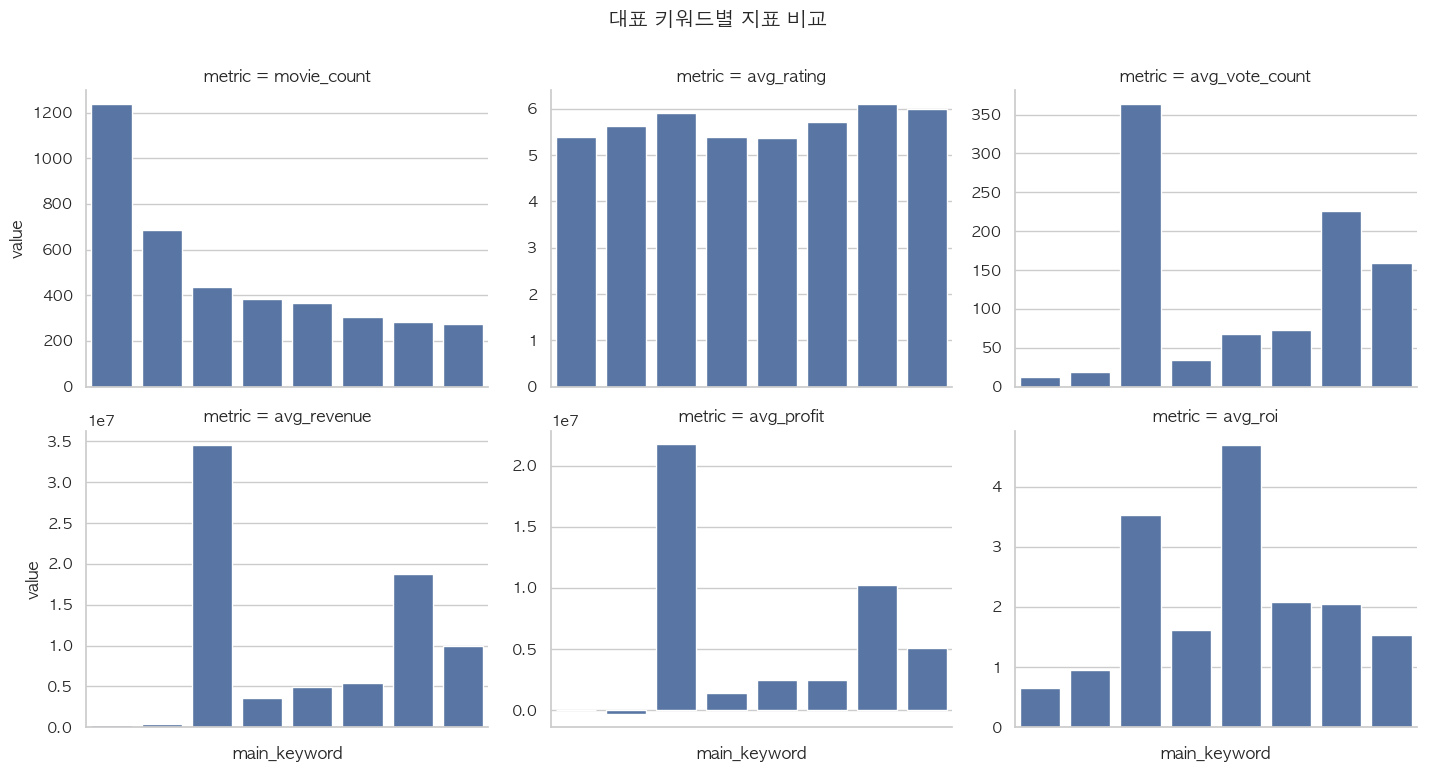

In [70]:
g = sns.catplot(
    data=keyword_business_long,
    x="main_keyword",
    y="value",
    col="metric",
    kind="bar",
    col_wrap=3,
    sharey=False,
    height=4,
    aspect=1.2,
)

g.set_xticklabels(rotation=45)
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("대표 키워드별 지표 비교")
plt.show()

## 17. 결과 저장

중간 테이블과 비즈니스 테이블을 저장합니다.

- `movies_with_keyword`: 조인과 파생 컬럼이 반영된 중간 테이블
- `year_business_table`: 연도별 요약 비즈니스 테이블
- `decade_keyword_pivot`: 연대 x 대표 키워드 pivot table
- `keyword_business_table_wide`: 대표 키워드별 wide table
- `keyword_business_table_long`: 시각화/후속 가공용 long table

In [71]:
year_summary.to_csv(YEAR_BUSINESS_PATH, index=False)
decade_keyword_pivot.to_csv(DECADE_KEYWORD_PIVOT_PATH)
keyword_business.to_csv(KEYWORD_BUSINESS_WIDE_PATH, index=False)
keyword_business_long.to_csv(KEYWORD_BUSINESS_LONG_PATH, index=False)

print("저장 완료:")
print("-", MOVIES_WITH_KEYWORD_PATH)
print("-", YEAR_BUSINESS_PATH)
print("-", DECADE_KEYWORD_PIVOT_PATH)
print("-", KEYWORD_BUSINESS_WIDE_PATH)
print("-", KEYWORD_BUSINESS_LONG_PATH)

저장 완료:
- ../data/output/movies_with_keyword.csv
- ../data/output/year_business_table.csv
- ../data/output/decade_keyword_pivot.csv
- ../data/output/keyword_business_table_wide.csv
- ../data/output/keyword_business_table_long.csv


## 정리

이번 실습에서는 다음 흐름을 확인했습니다.

```text
raw keywords.csv
→ keywords_clean
→ movies_clean과 inner join
→ movies_with_keyword 중간 테이블
→ groupby / pivot / melt 기반 business table
```

핵심은 `join`, `groupby`, `pivot_table`, `melt`를 각각 따로 외우는 것이 아니라, Transform 단계에서 테이블의 목적이 어떻게 달라지는지 이해하는 것입니다.